In [1]:
print("")

In [2]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

dataset_to_use = "generated_dataset.csv"
# dataset_to_use = "hiring_duration_merged.csv"

df = pd.read_csv(dataset_to_use, parse_dates=[
    "Submission Date", "Joining Date", "Sourcing Start", 
    "Interview Start", "Interview End", "Offered", "Filled"])

In [3]:
df.columns

Index(['Job Title', 'Job Location', 'Job Time Zone', 'Consultant Name', 'Visa',
       'Consultant Location', 'Consultant Time Zone', 'Salary ($1000)',
       'Relocation', 'Submission Date', 'Joining Date', 'Interview Status',
       'Hired', 'Sourcing Start', 'Interview Start', 'Interview End',
       'Offered', 'Filled'],
      dtype='object')

In [4]:
for column in df[['Job Title','Job Time Zone','Visa','Consultant Time Zone','Relocation', 'Interview Status', 'Hired']]:
    print(f"Column: {column}")
    print(f"Unique values: {df[column].unique()}")
    print(f"Number of unique values: {df[column].nunique()}")
    print("-" * 40)

Column: Job Title
Unique values: ['DevOps Engineer' 'Big Data' 'ETL' 'Java' 'SAP' 'Dot Net']
Number of unique values: 6
----------------------------------------
Column: Job Time Zone
Unique values: ['EST' 'PST' 'CST']
Number of unique values: 3
----------------------------------------
Column: Visa
Unique values: ['GC EAD' 'H1B' 'US Citizen' 'Green Card']
Number of unique values: 4
----------------------------------------
Column: Consultant Time Zone
Unique values: ['PST' 'CST' 'EST']
Number of unique values: 3
----------------------------------------
Column: Relocation
Unique values: ['Yes' 'No']
Number of unique values: 2
----------------------------------------
Column: Interview Status
Unique values: ['Cleared']
Number of unique values: 1
----------------------------------------
Column: Hired
Unique values: ['Y']
Number of unique values: 1
----------------------------------------


In [5]:
order=['Job Title', 'Job Location', 'Job Time Zone', 'Consultant Name', 'Visa',
       'Consultant Location', 'Consultant Time Zone', 'Salary ($1000)', 'Relocation',
       'Sourcing Start','Submission Date', 'Interview Start', 'Interview End',
       'Offered', 'Filled','Interview Status','Hired']
df = df[order]

In [6]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,$116K,Yes,2023-01-02,2023-01-04 00:00:00,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Y
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,$156K,Yes,2023-01-05,2023-01-08 01:12:00,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Y


In [7]:
# Strip whitespace from string fields
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# Fix salary format — convert "$110K" → 110000
df["Salary ($1000)"] = (
    df["Salary ($1000)"]
    .str.replace("$", "", regex=False)
    .str.replace("K", "", regex=False)
    .str.replace("k", "", regex=False)
    .astype(float) * 1000
)

In [8]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,2023-01-04 00:00:00,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Y
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,2023-01-08 01:12:00,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Y


In [9]:
# Standardize Yes/No flags
df["Relocation"] = df["Relocation"].str.title()
df["Hired"] = df["Hired"].replace({"Y": "Yes", "N": "No"})
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,2023-01-04 00:00:00,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Yes
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,2023-01-08 01:12:00,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Yes


In [10]:
# Convert Date Columns to Datetime
date_columns = [
    "Sourcing Start","Submission Date", 
    "Interview Start", "Interview End", "Offered", "Filled"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")  # done so that for example, these can be done: df['days_to_ship'] = (df['ship_date'] - df['order_date']).dt.days

In [11]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,2023-01-04 00:00:00,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Yes
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,2023-01-08 01:12:00,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Yes


In [12]:
df.to_csv('cleaned.csv')

In [13]:
# Interview duration (start → end)
df["Interview_Duration_Days"] = (
    df["Interview End"] - df["Interview Start"]
).dt.days

In [14]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Interview_Duration_Days
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,2023-01-04 00:00:00,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Yes,1
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,2023-01-08 01:12:00,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Yes,1


In [15]:
# Time from sourcing to offer
df["Days_Sourcing_to_Offer"] = (
    df["Offered"] - df["Sourcing Start"]
).dt.days

In [16]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Interview_Duration_Days,Days_Sourcing_to_Offer
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,2023-01-04 00:00:00,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Yes,1,9
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,2023-01-08 01:12:00,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Yes,1,11


In [17]:
job_summary = df.groupby("Job Title").agg({
    "Salary ($1000)": ["mean", "min", "max"],
    "Hired": lambda x: (x == "Yes").sum(),
    "Consultant Name": "count"
}).rename(columns={"Consultant Name": "Total Submitted"})
job_summary

Salary ($1000)                       Hired Total Submitted
                          mean      min       max <lambda>           count
Job Title                                                                 
Big Data         134900.000000  95000.0  184000.0       70              70
DevOps Engineer  138250.000000  97000.0  183000.0       76              76
Dot Net          140402.777778  95000.0  184000.0       72              72
ETL              140250.000000  95000.0  182000.0       64              64
Java             142796.296296  95000.0  183000.0       54              54
SAP              135718.750000  95000.0  181000.0       64              64

In [18]:
# Set Seaborn style
sns.set(style="whitegrid")

In [19]:
# # Salary Distribution by Job Title
# plt.figure(figsize=(10,6))
# sns.boxplot(data=df, x="Job Title", y="Salary ($1000)")
# plt.title("Salary Distribution by Job Title")
# plt.ylabel("Salary ($)")
# plt.xlabel("Job Title")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # Hired vs Not Hired by Job Title
# plt.figure(figsize=(10,6))
# sns.countplot(data=df, x="Job Title", hue="Hired")
# plt.title("Hired vs Not Hired by Job Title")
# plt.ylabel("Count")
# plt.xlabel("Job Title")
# plt.xticks(rotation=45)
# plt.legend(title="Hired")
# plt.tight_layout()
# plt.show()
# # Relocation Requirement by Job Title
# plt.figure(figsize=(10,6))
# sns.countplot(data=df, x="Job Title", hue="Relocation")
# plt.title("Relocation Requirement by Job Title")
# plt.ylabel("Count")
# plt.xlabel("Job Title")
# plt.xticks(rotation=45)
# plt.legend(title="Relocation")
# plt.tight_layout()
# plt.show()

In [20]:
# # Average Salary per Job Title
# avg_salary = df.groupby("Job Title")["Salary ($1000)"].mean().sort_values(ascending=False)
# avg_salary

In [21]:
# df.head(2)

In [22]:

# plt.figure(figsize=(10,6))
# sns.barplot(x=avg_salary.index, y=avg_salary.values, palette="viridis")
# plt.title("Average Salary per Job Title")
# plt.ylabel("Average Salary ($)")
# plt.xlabel("Job Title")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [23]:
# df.head(2)

In [24]:
# Time-to-Fill Analysis
# Calculate time-to-fill in days
df['Time_to_Fill'] = (df['Filled'] - df['Sourcing Start']).dt.days

In [25]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Interview_Duration_Days,Days_Sourcing_to_Offer,Time_to_Fill
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,2023-01-04 00:00:00,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Yes,1,9,13
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,2023-01-08 01:12:00,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Yes,1,11,17


In [26]:
# plt.figure(figsize=(10,5))
# sns.boxplot(x='Job Title', y='Time_to_Fill', data=df)
# plt.title('Time-to-Fill by Job Title')
# plt.xticks(rotation=45)
# plt.show()

In [27]:
# # Salary Analysis
# # Remove $ and K from Salary column and convert to numeric
# df['Salary ($1000)'] = df['Salary ($1000)'].replace('[\$,K]', '', regex=True).astype(float)

In [28]:
# df.head(2)

In [29]:

# Average, min, max salary per job title
salary_stats = df.groupby('Job Title')['Salary ($1000)'].agg(['mean', 'min', 'max']).reset_index()
salary_stats

,Job Title,mean,min,max
0,Big Data,134900.000000,95000.0,184000.0
1,DevOps Engineer,138250.000000,97000.0,183000.0
2,Dot Net,140402.777778,95000.0,184000.0
3,ETL,140250.000000,95000.0,182000.0
4,Java,142796.296296,95000.0,183000.0
5,SAP,135718.750000,95000.0,181000.0


In [30]:
# print("Salary Analysis per Job Title:")
# print(salary_stats)

In [31]:
df_hired = df[df['Hired'] == 'Yes']
# Visa Type Analysis
visa_counts = df_hired['Visa'].value_counts()
visa_counts

Visa
GC EAD        118
H1B            98
Green Card     93
US Citizen     91
Name: count, dtype: int64

In [32]:
# plt.figure(figsize=(6,4))
# sns.barplot(x=visa_counts.index, y=visa_counts.values)
# plt.title('Number of Hires by Visa Type')
# plt.ylabel('Number of Hires')
# plt.show()

In [33]:
# Relocation Analysis
relocation_counts = df_hired['Relocation'].value_counts()
relocation_counts

Relocation
Yes    229
No     171
Name: count, dtype: int64

In [34]:
# plt.figure(figsize=(6,4))
# sns.barplot(x=relocation_counts.index, y=relocation_counts.values)
# plt.title('Number of Hires with Relocation')
# plt.ylabel('Number of Hires')
# plt.show()
# df.isnull().sum()

In [35]:

df = df.dropna(subset=['Job Time Zone', 'Consultant Time Zone','Relocation'])
df.isnull().sum()

Job Title                  0
Job Location               0
Job Time Zone              0
Consultant Name            0
Visa                       0
Consultant Location        0
Consultant Time Zone       0
Salary ($1000)             0
Relocation                 0
Sourcing Start             0
Submission Date            0
Interview Start            0
Interview End              0
Offered                    0
Filled                     0
Interview Status           0
Hired                      0
Interview_Duration_Days    0
Days_Sourcing_to_Offer     0
Time_to_Fill               0
dtype: int64

In [36]:
other_date_cols = ["Interview_Duration_Days","Days_Sourcing_to_Offer","Time_to_Fill"]
df = df.drop(columns=other_date_cols)
df
df.isnull().sum()

Job Title               0
Job Location            0
Job Time Zone           0
Consultant Name         0
Visa                    0
Consultant Location     0
Consultant Time Zone    0
Salary ($1000)          0
Relocation              0
Sourcing Start          0
Submission Date         0
Interview Start         0
Interview End           0
Offered                 0
Filled                  0
Interview Status        0
Hired                   0
dtype: int64

In [37]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,2023-01-04 00:00:00,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Yes
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,2023-01-08 01:12:00,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Yes


In [38]:
# # Ensure datetime dtype
# date_cols = ["Sourcing Start","Submission Date", "Interview Start", "Interview End", "Offered", "Filled"]
# df[date_cols] = df[date_cols].apply(pd.to_datetime)

In [39]:
# df["Dur_Sourcing_to_Submission"] = df["Submission Date"] - df["Sourcing Start"]
df["Dur_Sourcing_to_Submission"] = (df["Submission Date"] - df["Sourcing Start"]).dt.days
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Dur_Sourcing_to_Submission
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,2023-01-04 00:00:00,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Yes,2
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,2023-01-08 01:12:00,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Yes,3


In [40]:
other_date_cols2 = ["Dur_Sourcing_to_Submission"]
df = df.drop(columns=other_date_cols2)

In [41]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,2023-01-04 00:00:00,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Yes
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,2023-01-08 01:12:00,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Yes


In [42]:
# df["Dur_Submission_to_InterviewStart"] = df["Interview Start"] - df["Submission Date"]
# df["Dur_InterviewStart_to_InterviewEnd"] = df["Interview End"] - df["Interview Start"]
# df["Dur_InterviewEnd_to_Offered"] = df["Offered"] - df["Interview End"]
# df["Dur_Offered_to_Filled"] = df["Filled"] - df["Offered"]


df["Dur_Submission_to_InterviewStart"] = (df["Interview Start"] - df["Submission Date"]).dt.days
df["Dur_InterviewStart_to_InterviewEnd"] = (df["Interview End"] - df["Interview Start"]).dt.days
df["Dur_InterviewEnd_to_Offered"] = (df["Offered"] - df["Interview End"]).dt.days
df["Dur_Offered_to_Filled"] = (df["Filled"] - df["Offered"]).dt.days

In [43]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,...,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Dur_Submission_to_InterviewStart,Dur_InterviewStart_to_InterviewEnd,Dur_InterviewEnd_to_Offered,Dur_Offered_to_Filled
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,...,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Yes,2,1,3,4
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,...,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Yes,3,1,3,5


In [44]:
# categorical = ["Job Title","Job Location","Visa","Consultant Location",
#                "Job Time Zone","Consultant Time Zone","Relocation","Interview Status"]
# df = pd.get_dummies(df, columns=categorical)

In [45]:
# # Get all column names as a list
# all_columns = df.columns.tolist()
# print(all_columns)
# print(f"Total columns: {len(all_columns)}")

# # Or print with indices
# for i, col in enumerate(df.columns):
#     print(f"{i}: {col}")

In [46]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,...,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Dur_Submission_to_InterviewStart,Dur_InterviewStart_to_InterviewEnd,Dur_InterviewEnd_to_Offered,Dur_Offered_to_Filled
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,...,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Yes,2,1,3,4
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,...,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Yes,3,1,3,5


In [47]:
other_date_cols3 = ['Dur_Submission_to_InterviewStart',
       'Dur_InterviewStart_to_InterviewEnd', 'Dur_InterviewEnd_to_Offered',
       'Dur_Offered_to_Filled']
df = df.drop(columns=other_date_cols3)

In [48]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,DevOps Engineer,"New York City, NY",EST,Consultant_0,GC EAD,"San Jose, CA",PST,116000.0,Yes,2023-01-02,2023-01-04 00:00:00,2023-01-06 09:36:00,2023-01-07 21:36:00,2023-01-11 18:26:31.823675,2023-01-15 18:26:31.823675,Cleared,Yes
1,Big Data,"San Jose, CA",PST,Consultant_1,H1B,"Dallas, TX",PST,156000.0,Yes,2023-01-05,2023-01-08 01:12:00,2023-01-11 04:48:00,2023-01-13 00:00:00,2023-01-16 20:24:00.000000,2023-01-22 01:12:00.000000,Cleared,Yes


In [49]:
# df[['Sourcing Start', 'Submission Date', 'Interview Start', 'Interview End', 'Offered', 'Filled']].to_csv("hello.csv")

In [50]:
import pandas as pd
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


class StageTracker:
    def __init__(self, df):
        self.df = df.copy()
        self.stages = ['Sourcing Start', 'Submission Date', 'Interview Start', 
                       'Interview End', 'Offered', 'Filled']
        self.durations = ['Dur_Sourcing_to_Submission', 'Dur_Submission_to_InterviewStart', 
                          'Dur_InterviewStart_to_InterviewEnd', 'Dur_InterviewEnd_to_Offered', 'Dur_Offered_to_Filled']
        self.features = [
            'Sourcing_start_day',
            'Sourcing_start_month',
            'Salary ($1000)'
        ]
        self.models = {}

    # --------------------------
    # Preprocessing
    # --------------------------
    def preprocess(self):
        for col in self.stages:
            self.df[col] = pd.to_datetime(self.df[col], errors='coerce')
            
        self.df['Salary ($1000)'] = pd.to_numeric(
            self.df['Salary ($1000)'], errors='coerce'
        )
            
        # Compute durations in days
        self.df['Dur_Sourcing_to_Submission'] = (self.df['Submission Date'] - self.df['Sourcing Start']).dt.total_seconds() / (3600*24)
        self.df['Dur_Submission_to_InterviewStart'] = (self.df['Interview Start'] - self.df['Submission Date']).dt.total_seconds() / (3600*24)
        self.df['Dur_InterviewStart_to_InterviewEnd'] = (self.df['Interview End'] - self.df['Interview Start']).dt.total_seconds() / (3600*24)
        self.df['Dur_InterviewEnd_to_Offered'] = (self.df['Offered'] - self.df['Interview End']).dt.total_seconds() / (3600*24)
        self.df['Dur_Offered_to_Filled'] = (self.df['Filled'] - self.df['Offered']).dt.total_seconds() / (3600*24)
        
        # Add simple features
        self.df['Sourcing_start_day'] = self.df['Sourcing Start'].dt.dayofweek
        self.df['Sourcing_start_month'] = self.df['Sourcing Start'].dt.month

    def printdf(self):
            print(self.df.head(2))
    # --------------------------
    # Train ML models for each stage
    # --------------------------
    def train_models(self):
        print("training happening")
        for dur in self.durations:
            valid_rows = self.df[self.df[dur].notna()]
            if len(valid_rows) == 0:
                continue
            X = valid_rows[self.features]
            print("X",X)
            y = valid_rows[dur]
            print("y",y)
            model = RandomForestRegressor(n_estimators=100, random_state=42)
            model.fit(X, y)
            self.models[dur] = model

    # --------------------------
    # Detect current stage
    # --------------------------
    def current_stage(self, record, current_time=None):
        if current_time is None:
            current_time = pd.Timestamp.now()
        last_stage = "Not Started"
        for stage in self.stages:
            ts = record.get(stage)
            if pd.isna(ts):
                break
            if pd.to_datetime(ts) <= current_time:
                last_stage = stage
            else:
                break
        return last_stage

    # --------------------------
    # Predict remaining stages
    # --------------------------
    def predict_remaining_stages(self, record, current_time=None):
        if current_time is None:
            current_time = pd.Timestamp.now()
        
        remaining_predictions = {}
        stage = self.current_stage(record, current_time)
        print("stage",stage)
        # Start prediction from last completed stage
        if stage == 'Filled':
            return remaining_predictions  # Nothing remaining
        
        start_index = self.stages.index(stage) + 1
        print("start_index",start_index)
        prev_stage = stage
        print("prev_stage",prev_stage)
        
        for i in range(start_index, len(self.stages)):
            next_stage = self.stages[i]
            # Map prev stage to duration
            stage_to_duration = {
                'Sourcing Start': 'Dur_Sourcing_to_Submission',
                'Submission Date': 'Dur_Submission_to_InterviewStart',
                'Interview Start': 'Dur_InterviewStart_to_InterviewEnd',
                'Interview End': 'Dur_InterviewEnd_to_Offered',
                'Offered': 'Dur_Offered_to_Filled'
            }
            
            model = self.models.get(stage_to_duration.get(prev_stage))
            if model is None:
                avg_duration = self.df[stage_to_duration.get(prev_stage)].mean()
                print("used average duration fallback")
            else:
                features_row = [[
                pd.to_datetime(record['Sourcing Start']).dayofweek,
                pd.to_datetime(record['Sourcing Start']).month,
                record.get('Salary ($1000)', self.df['Salary ($1000)'].mean())
            ]]

                avg_duration = model.predict(features_row)[0]
                print("used ML")
            
            prev_timestamp = record.get(prev_stage)
            if pd.isna(prev_timestamp):
                prev_timestamp = pd.Timestamp.now()
            
            predicted_timestamp = pd.to_datetime(prev_timestamp) + pd.Timedelta(days=avg_duration)
            remaining_predictions[next_stage] = predicted_timestamp
            prev_stage = next_stage  # update for next iteration
            record[prev_stage] = predicted_timestamp  # propagate predicted timestamp
        
        return remaining_predictions
    def evaluate_model_performance(self, test_size=0.2, random_state=42):
        """
        Evaluate model performance using train-test split
        """
        evaluation_results = {}
        
        for dur in self.durations:
            # Skip if no data
            valid_data = self.df[self.df[dur].notna()]
            if len(valid_data) < 10:  # Minimum data points
                continue
            
            # Train-test split
            from sklearn.model_selection import train_test_split
            X = valid_data[self.features]
            y = valid_data[dur]
            
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=random_state
            )
            
            # Train model
            model = RandomForestRegressor(n_estimators=100, random_state=42)
            model.fit(X_train, y_train)
            
            # Predictions
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
            
            evaluation_results[dur] = {
                'MAE_days': mae,
                'RMSE_days': rmse,
                'R2_score': r2,
                'MAPE_percent': mape,
                'samples_tested': len(y_test),
                'actual_mean_days': y_test.mean(),
                'predicted_mean_days': y_pred.mean()
            }
            
            # Store test predictions for analysis
            if not hasattr(self, 'test_predictions'):
                self.test_predictions = {}
            self.test_predictions[dur] = {
                'actual': y_test.values,
                'predicted': y_pred,
                'features': X_test.values
            }
        
        return evaluation_results
    
    def cross_validate_models(self, n_splits=5):
        """
        Perform cross-validation for more robust evaluation
        """
        from sklearn.model_selection import cross_val_score, KFold
        
        cv_results = {}
        
        for dur in self.durations:
            valid_data = self.df[self.df[dur].notna()]
            if len(valid_data) < n_splits * 2:  # Need enough data
                continue
            
            X = valid_data[self.features]
            y = valid_data[dur]
            
            model = RandomForestRegressor(n_estimators=100, random_state=42)
            
            # Cross-validation
            kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
            
            # Get multiple metrics
            mae_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
            rmse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
            r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
            
            cv_results[dur] = {
                'MAE_mean': -mae_scores.mean(),
                'MAE_std': mae_scores.std(),
                'RMSE_mean': -rmse_scores.mean(),
                'RMSE_std': rmse_scores.std(),
                'R2_mean': r2_scores.mean(),
                'R2_std': r2_scores.std()
            }
        
        return cv_results
    
    def evaluate_on_historical_candidates(self, sample_size=None):
        """
        Simulate predictions for historical candidates at various stages
        """
        results = []
        
        # Use sample if dataframe is large
        test_df = self.df if sample_size is None else self.df.sample(min(sample_size, len(self.df)))
        
        for idx, row in test_df.iterrows():
            # Simulate different current times (at each stage)
            for stage in self.stages:
                if pd.notna(row[stage]):
                    # Create record up to this stage
                    record = {}
                    for s in self.stages:
                        if self.stages.index(s) <= self.stages.index(stage):
                            record[s] = row[s]
                        else:
                            record[s] = pd.NaT
                    
                    # Predict remaining stages
                    current_time = pd.to_datetime(row[stage])
                    predictions = self.predict_remaining_stages(record, current_time)
                    
                    # Compare with actual values
                    for pred_stage, pred_date in predictions.items():
                        actual_date = row.get(pred_stage)
                        if pd.notna(actual_date):
                            error_days = (pred_date - pd.to_datetime(actual_date)).days
                            results.append({
                                'stage': pred_stage,
                                'error_days': error_days,
                                'actual_date': actual_date,
                                'predicted_date': pred_date,
                                'start_stage': stage
                            })
        
        return pd.DataFrame(results)
    
    def plot_error_distribution(self, evaluation_df):
        """
        Visualize prediction errors
        """
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, dur in enumerate(self.durations[:len(axes)]):
            if dur in self.test_predictions:
                actual = self.test_predictions[dur]['actual']
                predicted = self.test_predictions[dur]['predicted']
                errors = actual - predicted
                
                axes[idx].hist(errors, bins=20, edgecolor='black', alpha=0.7)
                axes[idx].axvline(x=0, color='r', linestyle='--', linewidth=2)
                axes[idx].set_title(f'{dur}\nMAE: {np.mean(np.abs(errors)):.1f} days')
                axes[idx].set_xlabel('Error (Actual - Predicted) days')
                axes[idx].set_ylabel('Frequency')
        
        plt.tight_layout()
        plt.show()


In [51]:
# # Ensure the features exist in the dataframe
# if 'Sourcing_start_day' not in df.columns:
#     df['Sourcing_start_day'] = pd.to_datetime(df['Sourcing Start']).dt.dayofweek
# if 'Sourcing_start_month' not in df.columns:
#     df['Sourcing_start_month'] = pd.to_datetime(df['Sourcing Start']).dt.month


In [52]:
# --------------------------
# Example usage
# --------------------------
tracker = StageTracker(df)

In [53]:
tracker.printdf()

         Job Title       Job Location Job Time Zone Consultant Name    Visa  \
0  DevOps Engineer  New York City, NY           EST    Consultant_0  GC EAD   
1         Big Data       San Jose, CA           PST    Consultant_1     H1B   

  Consultant Location Consultant Time Zone  Salary ($1000) Relocation  \
0        San Jose, CA                  PST        116000.0        Yes   
1          Dallas, TX                  PST        156000.0        Yes   

  Sourcing Start     Submission Date     Interview Start       Interview End  \
0     2023-01-02 2023-01-04 00:00:00 2023-01-06 09:36:00 2023-01-07 21:36:00   
1     2023-01-05 2023-01-08 01:12:00 2023-01-11 04:48:00 2023-01-13 00:00:00   

                     Offered                     Filled Interview Status Hired  
0 2023-01-11 18:26:31.823675 2023-01-15 18:26:31.823675          Cleared   Yes  
1 2023-01-16 20:24:00.000000 2023-01-22 01:12:00.000000          Cleared   Yes  


In [54]:
tracker.preprocess()

In [55]:
tracker.printdf()

         Job Title       Job Location Job Time Zone Consultant Name    Visa  \
0  DevOps Engineer  New York City, NY           EST    Consultant_0  GC EAD   
1         Big Data       San Jose, CA           PST    Consultant_1     H1B   

  Consultant Location Consultant Time Zone  Salary ($1000) Relocation  \
0        San Jose, CA                  PST        116000.0        Yes   
1          Dallas, TX                  PST        156000.0        Yes   

  Sourcing Start  ...                     Filled Interview Status Hired  \
0     2023-01-02  ... 2023-01-15 18:26:31.823675          Cleared   Yes   
1     2023-01-05  ... 2023-01-22 01:12:00.000000          Cleared   Yes   

  Dur_Sourcing_to_Submission Dur_Submission_to_InterviewStart  \
0                       2.00                             2.40   
1                       3.05                             3.15   

  Dur_InterviewStart_to_InterviewEnd Dur_InterviewEnd_to_Offered  \
0                                1.5                

In [56]:
tracker.train_models()

training happening
X      Sourcing_start_day  Sourcing_start_month  Salary ($1000)
0                     0                     1        116000.0
1                     3                     1        156000.0
2                     6                     1        103000.0
3                     2                     1        100000.0
4                     5                     1        174000.0
..                  ...                   ...             ...
395                   2                     4        172000.0
396                   5                     4         99000.0
397                   1                     4        177000.0
398                   4                     4        182000.0
399                   0                     4        178000.0

[400 rows x 3 columns]
y 0      2.000000
1      3.050000
2      4.100000
3      2.700000
4      3.750000
         ...   
395    3.300000
396    4.350000
397    2.950000
398    4.366095
399    2.600000
Name: Dur_Sourcing_to_Submission,

In [57]:

# New ongoing record
new_record = {
    'Sourcing Start': '2023-12-20 10:00:00',
    'Submission Date': '2023-12-23 10:00:00',
    'Interview Start': pd.NaT,
    'Interview End': pd.NaT,
    'Offered': pd.NaT,
    'Filled': pd.NaT,
    'Salary ($1000)': 120000
}


full_timeline = tracker.predict_remaining_stages(new_record)
print("Predicted future stages and timestamps:")
for stage, ts in full_timeline.items():
    print(f"{stage}: {ts}")


stage Submission Date
start_index 2
prev_stage Submission Date
used ML
used ML
used ML
used ML
Predicted future stages and timestamps:
Interview Start: 2023-12-27 11:05:08.742887999
Interview End: 2023-12-29 04:37:35.042659238
Offered: 2024-01-03 13:39:39.652234757
Filled: 2024-01-10 21:12:33.935298526


In [58]:

# 1. Basic model performance
print("=== Model Performance Evaluation ===")
performance = tracker.evaluate_model_performance()
for dur, metrics in performance.items():
    print(f"\n{dur}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.2f}")

=== Model Performance Evaluation ===

Dur_Sourcing_to_Submission:
  MAE_days: 0.12
  RMSE_days: 0.19
  R2_score: 0.97
  MAPE_percent: 2.98
  samples_tested: 80.00
  actual_mean_days: 4.01
  predicted_mean_days: 4.00

Dur_Submission_to_InterviewStart:
  MAE_days: 0.27
  RMSE_days: 0.39
  R2_score: 0.70
  MAPE_percent: 6.74
  samples_tested: 80.00
  actual_mean_days: 3.79
  predicted_mean_days: 3.71

Dur_InterviewStart_to_InterviewEnd:
  MAE_days: 0.05
  RMSE_days: 0.09
  R2_score: 0.80
  MAPE_percent: 2.60
  samples_tested: 80.00
  actual_mean_days: 1.81
  predicted_mean_days: 1.80

Dur_InterviewEnd_to_Offered:
  MAE_days: 0.29
  RMSE_days: 0.46
  R2_score: 0.79
  MAPE_percent: 6.15
  samples_tested: 80.00
  actual_mean_days: 4.71
  predicted_mean_days: 4.70

Dur_Offered_to_Filled:
  MAE_days: 0.35
  RMSE_days: 0.53
  R2_score: 0.81
  MAPE_percent: 5.63
  samples_tested: 80.00
  actual_mean_days: 6.30
  predicted_mean_days: 6.35


In [59]:
# 2. Cross-validation results
print("\n=== Cross-Validation Results ===")
cv_results = tracker.cross_validate_models()
for dur, metrics in cv_results.items():
    print(f"\n{dur}:")
    print(f"  MAE: {metrics['MAE_mean']:.1f} ± {metrics['MAE_std']:.1f} days")
    print(f"  RMSE: {metrics['RMSE_mean']:.1f} ± {metrics['RMSE_std']:.1f} days")
    print(f"  R²: {metrics['R2_mean']:.3f} ± {metrics['R2_std']:.3f}")


=== Cross-Validation Results ===

Dur_Sourcing_to_Submission:
  MAE: 0.1 ± 0.0 days
  RMSE: 0.2 ± 0.0 days
  R²: 0.954 ± 0.014

Dur_Submission_to_InterviewStart:
  MAE: 0.2 ± 0.0 days
  RMSE: 0.3 ± 0.1 days
  R²: 0.768 ± 0.048

Dur_InterviewStart_to_InterviewEnd:
  MAE: 0.0 ± 0.0 days
  RMSE: 0.1 ± 0.0 days
  R²: 0.856 ± 0.060

Dur_InterviewEnd_to_Offered:
  MAE: 0.3 ± 0.0 days
  RMSE: 0.4 ± 0.0 days
  R²: 0.718 ± 0.115

Dur_Offered_to_Filled:
  MAE: 0.4 ± 0.0 days
  RMSE: 0.5 ± 0.1 days
  R²: 0.788 ± 0.037


In [60]:
# 3. Historical simulation
print("\n=== Historical Simulation Results ===")
historical_results = tracker.evaluate_on_historical_candidates(sample_size=100)

if len(historical_results) > 0:
    print(f"Total predictions evaluated: {len(historical_results)}")
    
    # Summary statistics by stage
    stage_summary = historical_results.groupby('stage').agg({
        'error_days': ['mean', 'std', 'count', lambda x: np.mean(np.abs(x))]
    }).round(1)
    
    stage_summary.columns = ['mean_error', 'std_error', 'count', 'MAE']
    print("\nError statistics by stage:")
    print(stage_summary)
    
    # Overall statistics
    overall_mae = historical_results['error_days'].abs().mean()
    overall_std = historical_results['error_days'].std()
    accuracy_within_7_days = (historical_results['error_days'].abs() <= 7).mean() * 100
    
    print(f"\nOverall MAE: {overall_mae:.1f} days")
    print(f"Overall Std: {overall_std:.1f} days")
    print(f"Accuracy within 7 days: {accuracy_within_7_days:.1f}%")


=== Historical Simulation Results ===
stage Sourcing Start
start_index 1
prev_stage Sourcing Start
used ML
used ML
used ML
used ML
used ML
stage Submission Date
start_index 2
prev_stage Submission Date
used ML
used ML
used ML
used ML
stage Interview Start
start_index 3
prev_stage Interview Start
used ML
used ML
used ML
stage Interview End
start_index 4
prev_stage Interview End
used ML
used ML
stage Offered
start_index 5
prev_stage Offered
used ML
stage Filled
stage Sourcing Start
start_index 1
prev_stage Sourcing Start
used ML
used ML
used ML
used ML
used ML
stage Submission Date
start_index 2
prev_stage Submission Date
used ML
used ML
used ML
used ML
stage Interview Start
start_index 3
prev_stage Interview Start
used ML
used ML
used ML
stage Interview End
start_index 4
prev_stage Interview End
used ML
used ML
stage Offered
start_index 5
prev_stage Offered
used ML
stage Filled
stage Sourcing Start
start_index 1
prev_stage Sourcing Start
used ML
used ML
used ML
used ML
used ML
stage Su

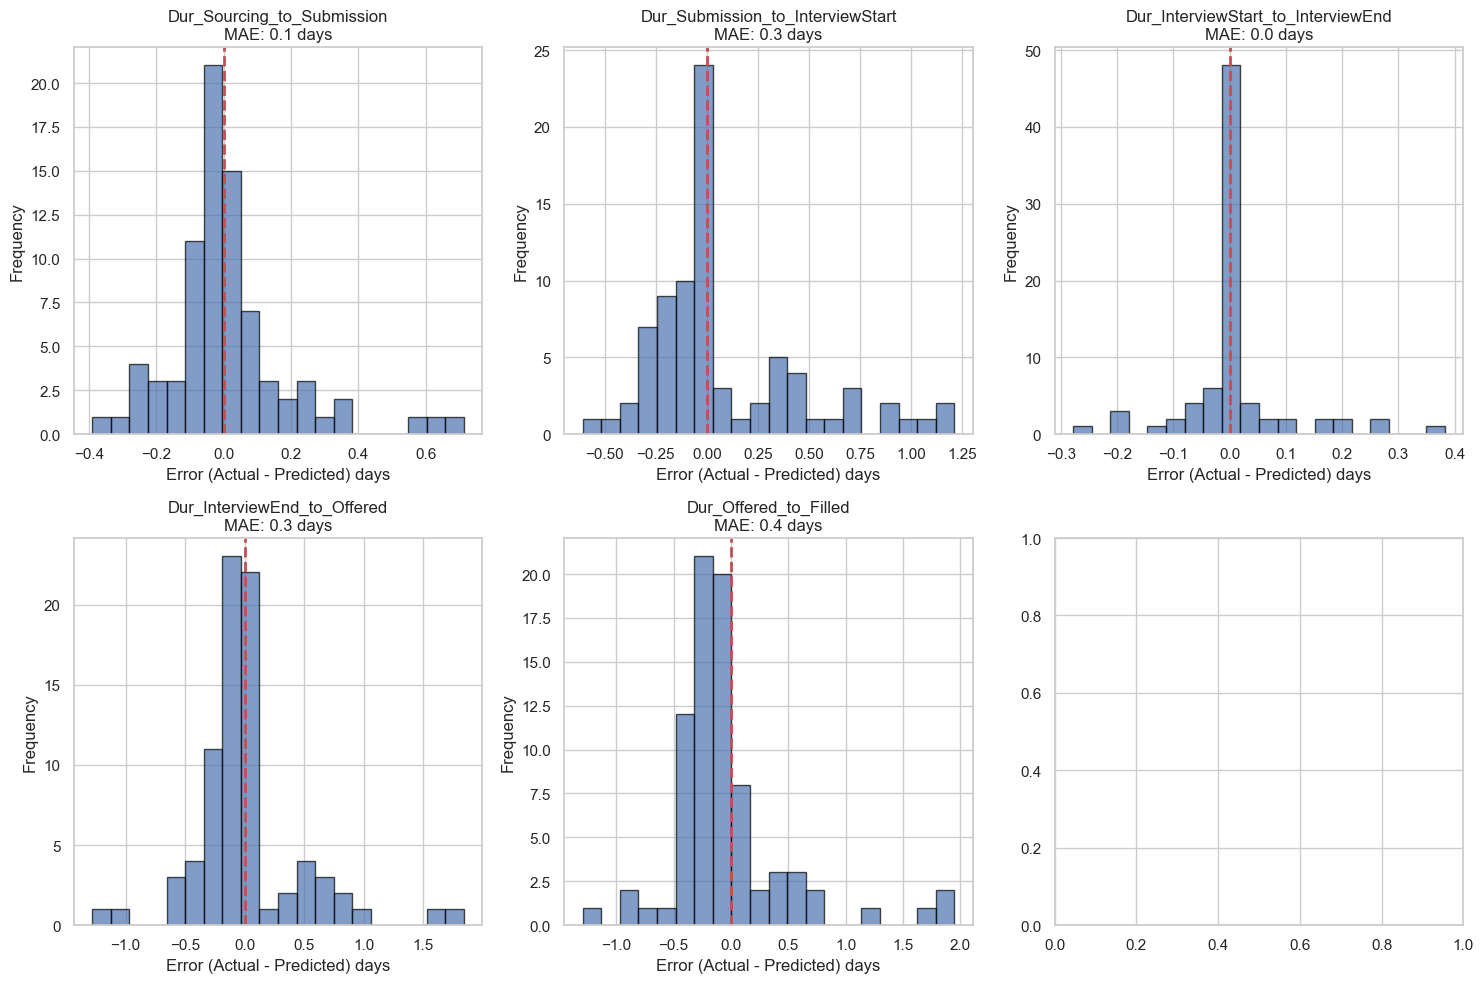

In [61]:

# 4. Visualize errors
if hasattr(tracker, 'test_predictions'):
    tracker.plot_error_distribution(historical_results)

In [62]:
# 5. Compare with baseline (simple average)
print("\n=== Comparison with Baseline (Simple Average) ===")
for dur in tracker.durations:
    if dur in tracker.df.columns:
        actual_values = tracker.df[dur].dropna()
        if len(actual_values) > 0:
            mean_value = actual_values.mean()
            mae_baseline = np.mean(np.abs(actual_values - mean_value))
            print(f"{dur}:")
            print(f"  Baseline MAE (using mean): {mae_baseline:.1f} days")
            if dur in performance:
                improvement = ((mae_baseline - performance[dur]['MAE_days']) / mae_baseline) * 100
                print(f"  Model improvement: {improvement:.1f}% better")


=== Comparison with Baseline (Simple Average) ===
Dur_Sourcing_to_Submission:
  Baseline MAE (using mean): 0.8 days
  Model improvement: 85.6% better
Dur_Submission_to_InterviewStart:
  Baseline MAE (using mean): 0.5 days
  Model improvement: 51.0% better
Dur_InterviewStart_to_InterviewEnd:
  Baseline MAE (using mean): 0.2 days
  Model improvement: 72.7% better
Dur_InterviewEnd_to_Offered:
  Baseline MAE (using mean): 0.7 days
  Model improvement: 60.2% better
Dur_Offered_to_Filled:
  Baseline MAE (using mean): 1.0 days
  Model improvement: 64.0% better


In [63]:
tracker.models.keys()

dict_keys(['Dur_Sourcing_to_Submission', 'Dur_Submission_to_InterviewStart', 'Dur_InterviewStart_to_InterviewEnd', 'Dur_InterviewEnd_to_Offered', 'Dur_Offered_to_Filled'])

In [64]:

# # New ongoing record
# new_record = {
#     'Sourcing Start': '2023-12-20 10:00:00',
#     'Submission Date': pd.NaT,
#     'Interview Start': pd.NaT,
#     'Interview End': pd.NaT,
#     'Offered': pd.NaT,
#     'Filled': pd.NaT
# }

# full_timeline = tracker.predict_remaining_stages(new_record)
# print("Predicted future stages and timestamps:")
# for stage, ts in full_timeline.items():
#     print(f"{stage}: {ts}")


In [65]:
# # Get all column names as a list
# all_columns = df.columns.tolist()
# print(all_columns)
# print(f"Total columns: {len(all_columns)}")

# # Or print with indices
# for i, col in enumerate(df.columns):
#     print(f"{i}: {col}")